<a href="https://colab.research.google.com/github/MatiasHerrneder/sistemas-inteligentes-2026/blob/main/mlp-vs-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción

# 2. Carga y Exploración de Datos

### Configuracion inicial

In [80]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


VALIDATION_SPLIT = 0.2

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# calcula media y std sobre todo el dataset
raw_dataset = datasets.FashionMNIST(root='./data', train=True, download=True,
                                     transform=transforms.ToTensor())

loader = DataLoader(raw_dataset, batch_size=512, shuffle=False)

mean = 0.0
std  = 0.0
n    = 0

for imgs, _ in loader:
    mean += imgs.mean(dim=[0, 2, 3])
    std  += imgs.std(dim=[0, 2, 3])
    n    += 1

mean /= n
std  /= n

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)) #type: ignore
])

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

val_size   = int(VALIDATION_SPLIT * len(train_full))
train_size = len(train_full) - val_size

# split reproducible
train_set, val_set = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(64))

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

### Forma del tensor

In [81]:
sample_img, sample_label = train_full[0]
shape = tuple(sample_img.shape)
print(f"Channels: {shape[0]}\nHeight: {shape[1]}\nWidth: {shape[2]}")

Channels: 1
Height: 28
Width: 28


### Imagenes de ejemplo

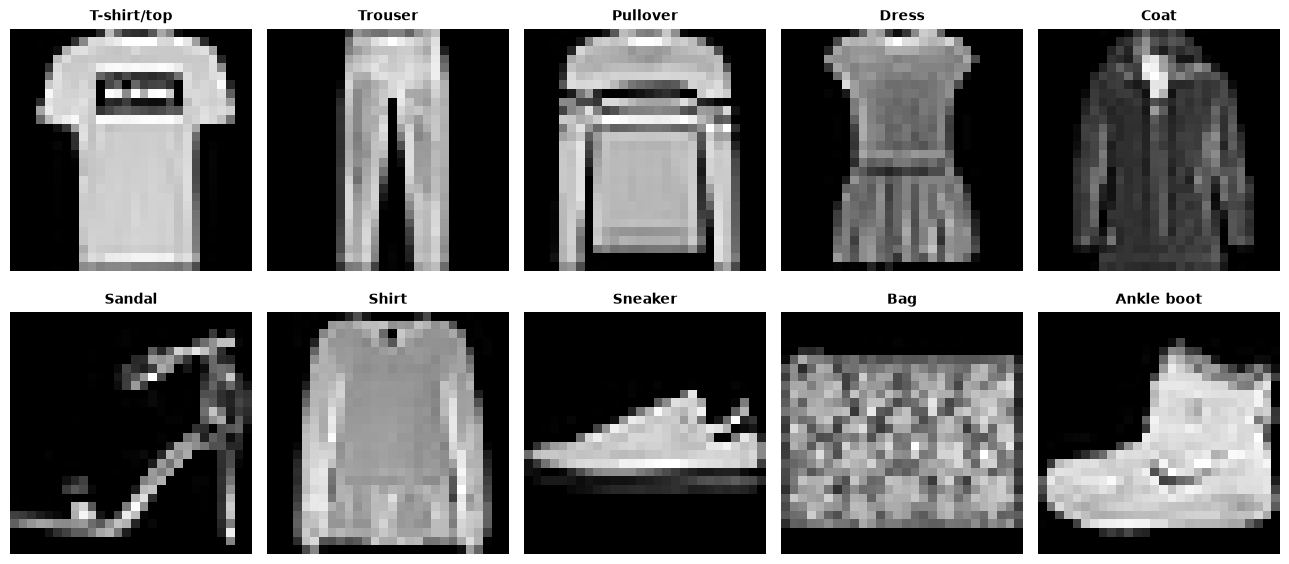

In [82]:
import matplotlib.pyplot as plt

def get_one_per_class(dataset, n_classes=10):
    found = {}
    for img, label in dataset:
        if label not in found:
            found[label] = img
        if len(found) == n_classes:
            break
    return [found[i] for i in range(n_classes)]

samples = get_one_per_class(train_full)

fig1, axes = plt.subplots(2, 5, figsize=(13, 6))

for ax, img, name in zip(axes.flat, samples, CLASS_NAMES):
    # Desnormalizar para mostrar [-1,1] -> [0,1]
    img_np = img.squeeze().numpy()
    img_np = (img_np * 0.5) + 0.5
    ax.imshow(img_np, cmap='gray')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Distribucion de clases

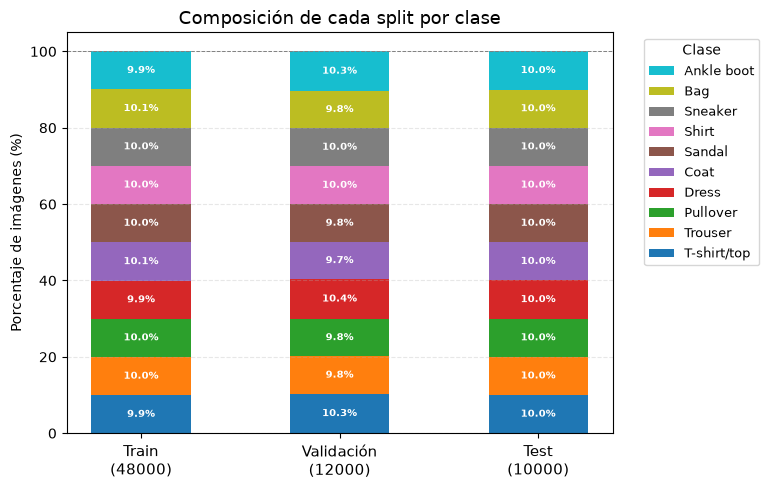

In [83]:
from collections import Counter
import numpy as np

def get_labels(subset):
    if hasattr(subset, 'dataset'):
        return [subset.dataset.targets[i].item() for i in subset.indices]
    else:
        return subset.targets.tolist()

train_labels = get_labels(train_set)
val_labels   = get_labels(val_set)
test_labels  = get_labels(test_set)

def label_counts(labels):
    c = Counter(labels)
    return [c[i] for i in range(10)]

splits = {
    f'Train\n({train_size})': label_counts(train_labels),
    f'Validación\n({val_size})': label_counts(val_labels),
    f'Test\n({len(test_set)})': label_counts(test_labels),
}

splits_pct = {
    name: np.array(counts) / sum(counts) * 100
    for name, counts in splits.items()
}

fig2, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(3)
x = np.arange(3)

for i, class_name in enumerate(CLASS_NAMES):
    values = np.array([splits_pct[split][i] for split in splits_pct])
    bars = ax.bar(x, values, bottom=bottom, label=class_name, width=0.5)

    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 1.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + val / 2,
                f'{val:.1f}%',
                ha='center', va='center', fontsize=7, color='white', fontweight='bold'
            )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(list(splits_pct.keys()), fontsize=11)
ax.set_ylabel("Porcentaje de imágenes (%)")
ax.set_title("Composición de cada split por clase", fontsize=13)
ax.set_ylim(0, 105)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.7)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    loc='upper right', bbox_to_anchor=(1.28, 1), fontsize=9, title="Clase"
)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Rango de valores de los pixeles

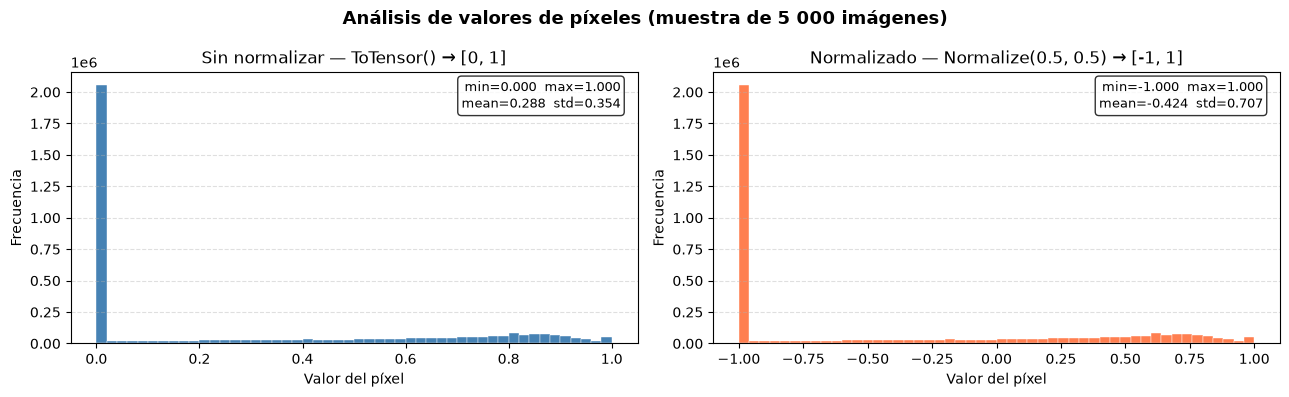

In [84]:
train_counts = label_counts(train_labels)

# calcula stats sobre píxeles RAW (sin normalizar) y normalizados
raw_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor()
)

# muestra aleatoria de 5000 imagenes
indices = torch.randperm(len(raw_dataset))[:5000]
sample_pixels_raw = torch.stack([raw_dataset[int(i)][0] for i in indices])
sample_pixels_norm = sample_pixels_raw * 2 - 1

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4))
fig3.suptitle("Análisis de valores de píxeles (muestra de 5 000 imágenes)", fontsize=13, fontweight='bold')

# histograma
ax = axes3[0]
flat_raw = sample_pixels_raw.flatten().numpy()
ax.hist(flat_raw, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title("Sin normalizar — ToTensor() → [0, 1]")
ax.set_xlabel("Valor del píxel")
ax.set_ylabel("Frecuencia")
stats_raw = f"min={flat_raw.min():.3f}  max={flat_raw.max():.3f}\nmean={flat_raw.mean():.3f}  std={flat_raw.std():.3f}"
ax.text(0.97, 0.97, stats_raw, transform=ax.transAxes,
        va='top', ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# histograma normalizado
ax2 = axes3[1]
flat_norm = sample_pixels_norm.flatten().numpy()
ax2.hist(flat_norm, bins=50, color='coral', edgecolor='white', linewidth=0.3)
ax2.set_title("Normalizado — Normalize(0.5, 0.5) → [-1, 1]")
ax2.set_xlabel("Valor del píxel")
ax2.set_ylabel("Frecuencia")
stats_norm = f"min={flat_norm.min():.3f}  max={flat_norm.max():.3f}\nmean={flat_norm.mean():.3f}  std={flat_norm.std():.3f}"
ax2.text(0.97, 0.97, stats_norm, transform=ax2.transAxes,
         va='top', ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Forma de las imagenes

In [85]:
shapes = set(raw_dataset[int(i)][0].shape for i in indices)
print(f"Formas únicas en el dataset: {shapes}")

Formas únicas en el dataset: {torch.Size([1, 28, 28])}


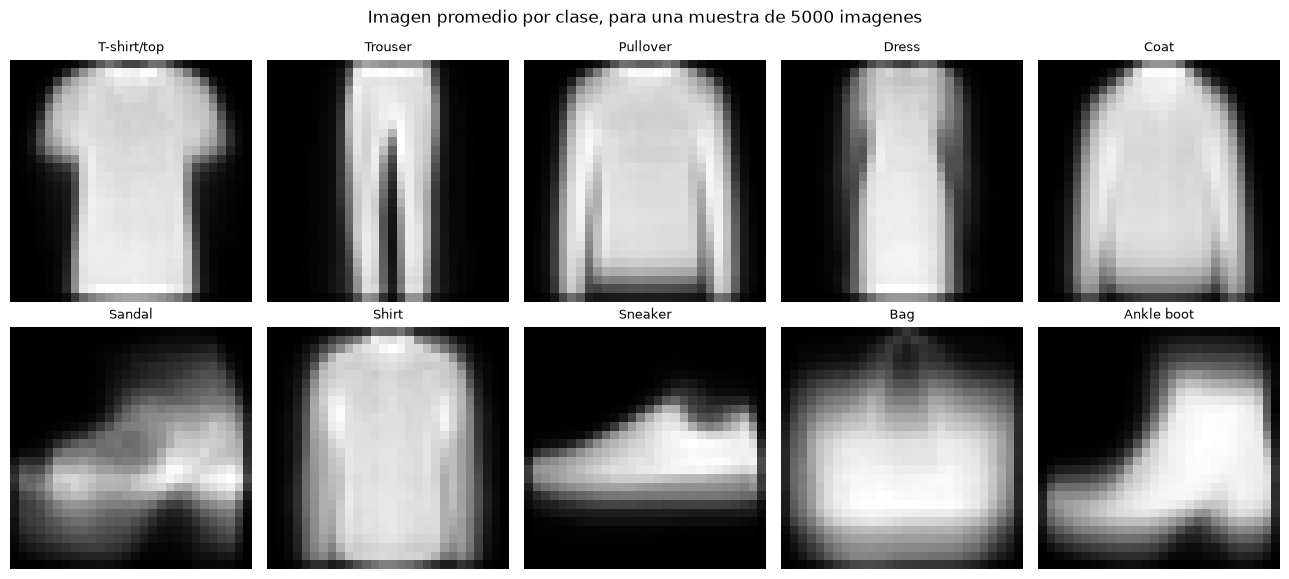

In [86]:
sample_size = min(len(raw_dataset), 5000)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle(f"Imagen promedio por clase, para una muestra de {sample_size} imagenes")

for class_idx, ax in enumerate(axes.flat):
    imgs = [raw_dataset[int(i)][0] for i in range(sample_size)
            if raw_dataset[int(i)][1] == class_idx]
    mean_img = torch.stack(imgs).mean(dim=0).squeeze()
    ax.imshow(mean_img, cmap='gray')
    ax.set_title(CLASS_NAMES[class_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Preprocesamiento

### Normalizacion de las imagenes
Al inicio de la parte 2, ya se normalizaron las imagenes, para poder hacer correctamente los calculos del analisis, con valores de media y desvio:

In [87]:
print(f"Mean: {mean.item():.4f}") # type: ignore
print(f"Std:  {std.item():.4f}") # type: ignore

Mean: 0.2862
Std:  0.3530


### Aplanado de imagenes

In [88]:
transform_mlp = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)),  # type: ignore
    transforms.Lambda(lambda x: x.view(-1))
])

# Cargar datasets
train_full_mlp = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform_mlp
)

test_set_mlp = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_mlp
)

# Split train/validation
val_size_mlp = int(VALIDATION_SPLIT * len(train_full_mlp))
train_size_mlp = len(train_full_mlp) - val_size_mlp

train_set_mlp, val_set_mlp = random_split(
    train_full_mlp,
    [train_size_mlp, val_size_mlp],
    generator=torch.Generator().manual_seed(64)
)

# DataLoaders
train_loader_mlp = DataLoader(train_set_mlp, batch_size=256, shuffle=True)
val_loader_mlp   = DataLoader(val_set_mlp, batch_size=256, shuffle=False)
test_loader_mlp  = DataLoader(test_set_mlp, batch_size=256, shuffle=False)

print("DataLoaders para MLP creados exitosamente.")
images, labels = next(iter(train_loader_mlp))
print(images.shape)

DataLoaders para MLP creados exitosamente.
torch.Size([256, 784])


# 4. Definición de los Modelos

## Modelo 1: MLP (MultiLayer Feedforward)

### Arquitectura MLP Base

In [89]:
import torch
import torch.nn as nn
import torch.optim as optim

class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

### Crear modelo, loss y optimizador

In [90]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_mlp = FashionMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_mlp.parameters(),
    lr=0.001
)

### Función de entrenamiento y evaluación

In [91]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

### Entrenamiento del modelo

In [92]:
# num_epochs = 15

# history = {
#     "train_loss": [],
#     "train_acc": [],
#     "val_loss": [],
#     "val_acc": []
# }

# for epoch in range(num_epochs):
#     train_loss, train_acc = train_one_epoch(
#         model_mlp,
#         train_loader_mlp,
#         criterion,
#         optimizer,
#         device
#     )

#     val_loss, val_acc = evaluate(
#         model_mlp,
#         val_loader_mlp,
#         criterion,
#         device
#     )

#     history["train_loss"].append(train_loss)
#     history["train_acc"].append(train_acc)
#     history["val_loss"].append(val_loss)
#     history["val_acc"].append(val_acc)

#     print(
#         f"Epoch [{epoch+1}/{num_epochs}] "
#         f"Train Loss: {train_loss:.4f} | "
#         f"Train Acc: {train_acc:.4f} | "
#         f"Val Loss: {val_loss:.4f} | "
#         f"Val Acc: {val_acc:.4f}"
#     )

### Evaluar en test

In [93]:
# from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt
# import numpy as np

# def get_predictions(model, loader, device):
#     model.eval()

#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for images, labels in loader:
#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model(images)
#             preds = torch.argmax(outputs, dim=1)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())

#     return np.array(all_labels), np.array(all_preds)

# class_names = [
#     "T-shirt/top",
#     "Trouser",
#     "Pullover",
#     "Dress",
#     "Coat",
#     "Sandal",
#     "Shirt",
#     "Sneaker",
#     "Bag",
#     "Ankle boot"
# ]

# y_true, y_pred = get_predictions(model_mlp, test_loader_mlp, device)

# print(classification_report(
#     y_true,
#     y_pred,
#     target_names=class_names,
#     digits=4
# ))

# cm = confusion_matrix(y_true, y_pred)

# disp = ConfusionMatrixDisplay(
#     confusion_matrix=cm,
#     display_labels=class_names
# )

# fig, ax = plt.subplots(figsize=(10, 10))
# disp.plot(ax=ax, xticks_rotation=45)
# plt.title("Matriz de confusión - MLP")
# plt.show()

# test_loss, test_acc = evaluate(
#     model_mlp,
#     test_loader_mlp,
#     criterion,
#     device
# )

# print(f"Test Loss: {test_loss:.4f}")
# print(f"Test Accuracy: {test_acc:.4f}")

In [94]:
class FlexibleMLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size, activation, dropout):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(activation())
            layers.append(nn.Dropout(dropout))
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, output_size))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [95]:
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [96]:
def get_optimizer(name, model, lr):
    if name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)

    elif name == "SGD":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    elif name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=lr)

    else:
        raise ValueError(f"Optimizador no soportado: {name}")

In [97]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

    return history

In [98]:
experiments = [
    {
        "name": "MLP_256_128_ReLU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.ReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_512_256_128_ReLU_Adam",
        "hidden_layers": [512, 256, 128],
        "activation": nn.ReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_256_128_LeakyReLU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.LeakyReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_256_128_GELU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.GELU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_512_256_ReLU_RMSprop",
        "hidden_layers": [512, 256],
        "activation": nn.ReLU,
        "dropout": 0.2,
        "optimizer": "RMSprop",
        "lr": 0.0005,
        "epochs": 15
    }
]

In [99]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.optim as optim

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# results = []

# criterion = nn.CrossEntropyLoss()

# for exp in experiments:
#     print(f"Entrenando experimento: {exp['name']}")

#     model = FlexibleMLP(
#         input_size=784,
#         hidden_layers=exp["hidden_layers"],
#         output_size=10,
#         activation=exp["activation"],
#         dropout=exp["dropout"]
#     ).to(device)

#     optimizer = get_optimizer(
#         name=exp["optimizer"],
#         model=model,
#         lr=exp["lr"]
#     )

#     history = train_model(
#         model=model,
#         train_loader=train_loader_mlp,
#         val_loader=val_loader_mlp,
#         criterion=criterion,
#         optimizer=optimizer,
#         device=device,
#         num_epochs=exp["epochs"]
#     )

#     y_true, y_pred = get_predictions(
#         model,
#         test_loader_mlp,
#         device
#     )

#     test_acc = accuracy_score(y_true, y_pred)
#     test_precision = precision_score(y_true, y_pred, average="macro")
#     test_recall = recall_score(y_true, y_pred, average="macro")
#     test_f1 = f1_score(y_true, y_pred, average="macro")

#     results.append({
#         "model": exp["name"],
#         "hidden_layers": exp["hidden_layers"],
#         "activation": exp["activation"].__name__,
#         "dropout": exp["dropout"],
#         "optimizer": exp["optimizer"],
#         "lr": exp["lr"],
#         "epochs": exp["epochs"],
#         "final_train_loss": history["train_loss"][-1],
#         "final_train_acc": history["train_acc"][-1],
#         "final_val_loss": history["val_loss"][-1],
#         "final_val_acc": history["val_acc"][-1],
#         "test_acc": test_acc,
#         "test_precision_macro": test_precision,
#         "test_recall_macro": test_recall,
#         "test_f1_macro": test_f1
#     })

#     print(f"Finalizado: {exp['name']}")
#     print(f"Test Accuracy: {test_acc:.4f}")
#     print(f"Test F1 Macro: {test_f1:.4f}")
#     print("-" * 50)

In [100]:
# results_df = pd.DataFrame(results)

# results_df = results_df.sort_values(
#     by=["test_acc", "test_f1_macro"],
#     ascending=False
# )

# results_df

## Modelo 2: CNN (Convolucional)

### Arquitectura CNN Base

In [101]:
import torch
from torch import optim
from torch import nn
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import Literal

# import torchvision

import torch.nn.functional as F
# import torchvision.datasets as datasets
# import torchvision.transforms as transforms

############################
# configuracion de la cnn
############################
@dataclass
class ConvLayerConfig:
    out_channels: int
    kernel_size: int = 3
    padding: int = 1
    activation: Literal["relu", "tanh", "leaky_relu", "elu", "none"] = "relu"
    pooling: Literal["max", "avg", "none"] = "max"
    use_batchnorm: bool = False
    dropout_p: float = 0.0

@dataclass
class LinearLayerConfig:
    out_features: int
    activation: Literal["relu", "tanh", "leaky_relu", "elu", "none"] = "relu"
    dropout_p: float = 0.0

@dataclass
class TrainConfig:
    num_epochs:   int   = 10
    lr:           float = 0.001
    weight_decay: float = 0.0   # L2 — 0.0 = desactivado
    l1_lambda:    float = 0.0   # L1 — 0.0 = desactivado
    patience:     int   = 0     # early stopping — 0 = desactivado


##################
# helpers
##################
ACTIVATIONS = {
    "relu":       nn.ReLU(),
    "tanh":       nn.Tanh(),
    "leaky_relu": nn.LeakyReLU(),
    "elu":        nn.ELU(),
    "none":       nn.Identity(),
}

POOLING = {
    "max": nn.MaxPool2d(kernel_size=2, stride=2),
    "avg": nn.AvgPool2d(kernel_size=2, stride=2),
    "none": nn.Identity(),
}


######################
# modelo
######################
class CNN(nn.Module):
    def __init__(
        self, 
        in_channels: int, 
        input_size: int, # ancho, alto de la img
        num_classes: int,
        conv_layers: list[ConvLayerConfig],
        linear_layers: list[LinearLayerConfig],
        ):
       
        super().__init__()

        conv_blocks = []
        current_channels = in_channels

        for cfg in conv_layers:
            conv_blocks += [
                nn.Conv2d(current_channels, cfg.out_channels,
                          kernel_size=cfg.kernel_size, padding=cfg.padding),
                nn.BatchNorm2d(cfg.out_channels) if cfg.use_batchnorm else nn.Identity(),
                ACTIVATIONS[cfg.activation],
                POOLING[cfg.pooling],
                nn.Dropout2d(cfg.dropout_p) if cfg.dropout_p > 0 else nn.Identity(),
            ]
            current_channels = cfg.out_channels
            if cfg.pooling != "none":
                input_size //= 2

        self.conv_net = nn.Sequential(*conv_blocks)

        flatten_size = current_channels * input_size * input_size
        linear_blocks = []
        current_features = flatten_size

        for cfg in linear_layers:
            linear_blocks += [
                nn.Linear(current_features, cfg.out_features),
                ACTIVATIONS[cfg.activation],
                nn.Dropout(cfg.dropout_p) if cfg.dropout_p > 0 else nn.Identity(),
            ]
            current_features = cfg.out_features

        linear_blocks.append(nn.Linear(current_features, num_classes))
        self.linear_net = nn.Sequential(*linear_blocks)


    def forward(self, x):
        x = self.conv_net(x)
        x = x.reshape(x.shape[0], -1)
        x = self.linear_net(x)
        return x


### Función de entrenamiento y evaluación

In [102]:
def train(
    model: CNN,
    train_loader,
    cfg: TrainConfig,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    history = {"train_loss": []}

    for epoch in range(cfg.num_epochs):
        model.train()
        train_loss = 0.0

        for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}"):
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            scores = model(data)
            loss   = criterion(scores, targets)

            if cfg.l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss    = loss + cfg.l1_lambda * l1_norm

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        history["train_loss"].append(train_loss)
        print(f"  train_loss: {train_loss:.4f}")

    return model, history

### Test

In [103]:
# import os


# FORCE_RETRAIN = False


# experiments = [
#     {
#         "name": "baseline",
#         "conv_layers": [
#             ConvLayerConfig(out_channels=8),
#             ConvLayerConfig(out_channels=16),
#         ],
#         "linear_layers": [
#             LinearLayerConfig(out_features=128),
#         ],
#         "train_cfg": TrainConfig(),
#     },
#     {
#         "name": "l2 + dropout",
#         "conv_layers": [
#             ConvLayerConfig(out_channels=32, use_batchnorm=True),
#             ConvLayerConfig(out_channels=64, use_batchnorm=True, dropout_p=0.25),
#         ],
#         "linear_layers": [
#             LinearLayerConfig(out_features=256, dropout_p=0.5),
#             LinearLayerConfig(out_features=128, dropout_p=0.25),
#         ],
#         "train_cfg": TrainConfig(weight_decay=1e-4, patience=3),
#     },
#     {
#         "name": "l1 + early stopping",
#         "conv_layers": [
#             ConvLayerConfig(out_channels=32, use_batchnorm=True),
#             ConvLayerConfig(out_channels=64, use_batchnorm=True),
#         ],
#         "linear_layers": [
#             LinearLayerConfig(out_features=128),
#         ],
#         "train_cfg": TrainConfig(l1_lambda=1e-5, patience=3),
#     },
#     {
#         "name": "todo",
#         "conv_layers": [
#             ConvLayerConfig(out_channels=32, use_batchnorm=True, activation="leaky_relu"),
#             ConvLayerConfig(out_channels=64, use_batchnorm=True, dropout_p=0.25),
#         ],
#         "linear_layers": [
#             LinearLayerConfig(out_features=256, dropout_p=0.5),
#             LinearLayerConfig(out_features=128, dropout_p=0.25),
#         ],
#         "train_cfg": TrainConfig(l1_lambda=1e-5, weight_decay=1e-4, patience=3),
#     },
# ]

# trained_models = {}
# results = {}
# save_path = "models"
# os.makedirs(save_path, exist_ok=True)

# for exp in experiments:
#     print(f"\n{'='*40}\nExperimento: {exp['name']}\n{'='*40}")

#     model = CNN(
#         in_channels=1,
#         input_size=28,
#         num_classes=10,
#         conv_layers=exp["conv_layers"],
#         linear_layers=exp["linear_layers"],
#     )

#     model_path = os.path.join(save_path, f"{exp['name']}_final.pth")

#     if not FORCE_RETRAIN and os.path.exists(model_path):
#         print(f"  Cargando modelo existente desde {model_path}")
#         model.load_state_dict(torch.load(model_path))
#         results[exp["name"]] = None  # no hay history si no se entreno
#     else:
#         model, history = train(model, train_loader, cfg=exp["train_cfg"])
#         torch.save(model.state_dict(), model_path)
#         results[exp["name"]] = history

#     model.eval()
#     trained_models[exp["name"]] = model

### Evaluacion

In [104]:
# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# device = "cuda" if torch.cuda.is_available() else "cpu"

# for name, model in trained_models.items():
#     print(f"\n{'='*40}\nEvaluación: {name}\n{'='*40}")

#     model.to(device)
#     model.eval()
#     all_preds, all_targets = [], []

#     with torch.no_grad():
#         for data, targets in val_loader:
#             data = data.to(device)
#             preds = model(data).argmax(dim=1).cpu()
#             all_preds.extend(preds.tolist())
#             all_targets.extend(targets.tolist())

#     # Métricas
#     print(classification_report(all_targets, all_preds))

#     # Matriz de confusión
#     cm = confusion_matrix(all_targets, all_preds)
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
#     plt.title(f"Confusion Matrix — {name}")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.tight_layout()
#     plt.show()

### Load and save models

# 5. Experimentación

## 5.1 Metodología de evaluación

Buscamos el **mejor MLP** y la **mejor CNN** para FashionMNIST y luego los comparamos.

**Validación — k-fold cross validation estratificada (k=5).**
El train está perfectamente balanceado (6.000 imágenes por clase), así que un k-fold simple
ya sería válido; usamos la versión **estratificada** porque garantiza la misma proporción de
clases en cada fold sin costo extra y hace la estimación más robusta frente a una partición
aleatoria desafortunada (el riesgo que marcaba el README). Reportamos la **media ± desvío**
entre folds.

**Early stopping.** Dentro de cada fold reservamos un pequeño split interno (15 %) del train
del fold para monitorear la *loss* de validación. Si no mejora durante `PATIENCE` épocas,
cortamos y restauramos los mejores pesos. El set de evaluación del fold **no** se usa para
parar (no hay fuga). `num_epochs` pasa a ser un *tope máximo* de épocas.

**Métricas** (todas *macro*, las 10 clases pesan igual):
`accuracy`, `precision`, `recall`, `f1-score`, **ROC-AUC** (one-vs-rest) y **matriz de
confusión** agregada sobre todos los folds.

**Cache / guardado de modelos.** Para no reentrenar en cada ejecución:
- Los resultados de CV se cachean en `models/cv_cache/<nombre>.pkl`.
- Los modelos finales se guardan como `models/<nombre>_final.pth` y se cargan si existen.
- El cache se indexa por **nombre**: si cambiás la configuración, **cambiá también el nombre**
  (o poné `FORCE_RECOMPUTE = True`) para que recalcule.

**Proceso de selección**
1. **Ronda 1:** 3 configuraciones por arquitectura → elegimos la mejor por `f1_mean`.
2. **Tuning incremental:** cambiamos **un hiperparámetro a la vez** y re-evaluamos con CV.
3. **Evaluación final:** reentrenamos el mejor de cada arquitectura sobre **todo** el train y
   lo medimos en `test_set` (held-out, nunca usado en la selección).

### Harness de cross-validation (compartido por MLP y CNN)

In [ ]:
import os, re, copy, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Rendimiento: autotune de cuDNN (input fijo 28x28) y kwargs comunes de DataLoader ---
torch.backends.cudnn.benchmark = True


In [ ]:
# === Precarga del dataset en GPU (clave de rendimiento) =============================
# Los modelos son chicos: el cuello de botella era preparar cada batch en CPU (PIL + transform).
# Materializamos TODO el dataset como tensores residentes en GPU una sola vez y batcheamos
# indexando -> sin DataLoader, sin transform por batch, sin copias host->device en cada paso.

def _to_gpu_tensors(ds):
    loader = DataLoader(ds, batch_size=4096, shuffle=False, num_workers=4)
    xs, ys = zip(*[(xb, yb) for xb, yb in loader])
    return torch.cat(xs).to(device), torch.cat(ys).to(device)

X_train_gpu, Y_train_gpu = _to_gpu_tensors(train_full)
X_test_gpu,  Y_test_gpu  = _to_gpu_tensors(test_set)
print(f"Train en GPU: {tuple(X_train_gpu.shape)} {X_train_gpu.dtype} @ {X_train_gpu.device} "
      f"({X_train_gpu.element_size() * X_train_gpu.nelement() / 1e6:.0f} MB)")
print(f"Test  en GPU: {tuple(X_test_gpu.shape)}")


In [ ]:
def make_loader(dataset, batch_size, shuffle):
    """DataLoader con kwargs de rendimiento (workers en paralelo + pinned memory)."""
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=4, pin_memory=torch.cuda.is_available(),
                      persistent_workers=True)

class GPULoader:
    """Itera (xb, yb) ya en GPU indexando tensores residentes. Reemplazo directo del DataLoader
    para datasets que entran en memoria de GPU: elimina el overhead de CPU/transfer por batch."""
    def __init__(self, X, Y, indices=None, batch_size=512, shuffle=False):
        self.X, self.Y = X, Y
        self.idx = (torch.arange(X.shape[0], device=X.device) if indices is None
                    else torch.as_tensor(indices, dtype=torch.long, device=X.device))
        self.batch_size, self.shuffle = batch_size, shuffle
    def __iter__(self):
        idx = self.idx
        if self.shuffle:
            idx = idx[torch.randperm(idx.numel(), device=idx.device)]
        for i in range(0, idx.numel(), self.batch_size):
            b = idx[i:i + self.batch_size]
            yield self.X[b], self.Y[b]
    def __len__(self):
        return (self.idx.numel() + self.batch_size - 1) // self.batch_size

# Dataset base normalizado (imágenes [1,28,28]) y etiquetas para estratificar.
# train_full se definió en la celda de carga (sección 2).
cv_dataset = train_full
cv_labels  = np.array(train_full.targets)

N_SPLITS        = 5
SEED            = 42
PATIENCE        = 3      # early stopping: épocas sin mejora antes de cortar (0 = desactivado)
INNER_VAL_FRAC  = 0.15   # porción de cada fold reservada para monitorear early stopping
FORCE_RECOMPUTE = False  # True = ignora cache y recalcula / reentrena todo

CV_CACHE_DIR = "models/cv_cache"
FINAL_DIR    = "models"
os.makedirs(CV_CACHE_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)


def _slug(name):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("_")


# --- MLP que acepta imágenes [B,1,28,28] (aplana adentro) para usar el mismo loop que la CNN ---
class MLPForCV(nn.Module):
    def __init__(self, hidden_layers, activation, dropout):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = FlexibleMLP(784, hidden_layers, 10, activation, dropout)
    def forward(self, x):
        return self.net(self.flatten(x))


def build_cnn(conv_layers, linear_layers):
    """Atajo para crear una CNN con la firma fija de FashionMNIST."""
    return CNN(in_channels=1, input_size=28, num_classes=10,
               conv_layers=conv_layers, linear_layers=linear_layers)


@torch.no_grad()
def _val_loss(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        total += criterion(model(x), y).item() * x.size(0)
        n += x.size(0)
    return total / n


def _fit(model, train_loader, val_loader, criterion, optimizer,
         max_epochs, l1_lambda=0.0, patience=PATIENCE):
    """Entrena con early stopping (si patience>0 y hay val_loader) y restaura los mejores pesos."""
    best_loss, best_state, no_improve = float("inf"), None, 0
    for _ in range(max_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            if l1_lambda > 0:
                loss = loss + l1_lambda * sum(p.abs().sum() for p in model.parameters())
            loss.backward()
            optimizer.step()
        if patience > 0 and val_loader is not None:
            vloss = _val_loss(model, val_loader, criterion)
            if vloss < best_loss - 1e-4:
                best_loss, best_state, no_improve = vloss, copy.deepcopy(model.state_dict()), 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def _predict(model, loader):
    """Devuelve (y_true, y_pred, y_proba) — y_proba son probabilidades softmax para ROC."""
    model.eval()
    probas, trues = [], []
    for x, y in loader:
        probas.append(torch.softmax(model(x.to(device, non_blocking=True)), dim=1).cpu())
        trues.extend(y.tolist())
    probas = torch.cat(probas).numpy()
    return np.array(trues), probas.argmax(1), probas


def _metrics(y_true, y_pred, y_proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }


def cross_validate(name, model_fn, build_optimizer, num_epochs,
                   n_splits=N_SPLITS, l1_lambda=0.0, patience=PATIENCE,
                   batch_size=512, verbose=True) -> tuple:
    """
    Evalúa UNA configuración con StratifiedKFold + early stopping. Cachea el resultado.

    model_fn        : función sin args que devuelve un modelo nuevo (lambda: MLPForCV(...))
    build_optimizer : función modelo -> optimizador (permite lr, weight_decay, etc.)
    Devuelve (summary dict, df por fold, matriz de confusión agregada).
    """
    cache_path = os.path.join(CV_CACHE_DIR, _slug(name) + ".pkl")
    if not FORCE_RECOMPUTE and os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            summary, df, cm = pickle.load(f)
        if verbose:
            print(f"  [{name}] cargado de cache  "
                  f"(acc={summary['acc_mean']:.4f}  f1={summary['f1_mean']:.4f}  roc={summary['roc_mean']:.4f})")
        return summary, df, cm

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    criterion = nn.CrossEntropyLoss()
    rows, cm_total = [], np.zeros((10, 10), dtype=int)

    for fold, (tr, va) in enumerate(skf.split(cv_labels, cv_labels), 1):
        torch.manual_seed(SEED)                       # init reproducible entre configs
        model = model_fn().to(device)
        optimizer = build_optimizer(model)

        # split interno para early stopping (no toca el set de evaluación del fold)
        if patience > 0:
            inner_tr, inner_va = train_test_split(
                tr, test_size=INNER_VAL_FRAC, random_state=SEED, stratify=cv_labels[tr])
            train_loader = GPULoader(X_train_gpu, Y_train_gpu, inner_tr, batch_size, True)
            es_loader    = GPULoader(X_train_gpu, Y_train_gpu, inner_va, batch_size, False)
        else:
            train_loader = GPULoader(X_train_gpu, Y_train_gpu, tr, batch_size, True)
            es_loader    = None

        val_loader = GPULoader(X_train_gpu, Y_train_gpu, va, batch_size, False)

        _fit(model, train_loader, es_loader, criterion, optimizer, num_epochs, l1_lambda, patience)
        y_true, y_pred, y_proba = _predict(model, val_loader)

        m = _metrics(y_true, y_pred, y_proba)
        m["fold"] = fold
        rows.append(m)
        cm_total += confusion_matrix(y_true, y_pred, labels=list(range(10)))
        if verbose:
            print(f"  [{name}] fold {fold}/{n_splits}  acc={m['accuracy']:.4f}  "
                  f"f1={m['f1']:.4f}  roc={m['roc_auc']:.4f}")

    df = pd.DataFrame(rows)
    summary = {
        "model":     name,
        "acc_mean":  df["accuracy"].mean(),  "acc_std": df["accuracy"].std(),
        "prec_mean": df["precision"].mean(),
        "rec_mean":  df["recall"].mean(),
        "f1_mean":   df["f1"].mean(),        "f1_std":  df["f1"].std(),
        "roc_mean":  df["roc_auc"].mean(),
    }
    with open(cache_path, "wb") as f:
        pickle.dump((summary, df, cm_total), f)
    return summary, df, cm_total


def run_round(configs) -> tuple:
    """Corre cross_validate sobre una lista de configs y devuelve (tabla ordenada, dict de CMs)."""
    summaries, cms = [], {}
    for cfg in configs:
        print(f"\n=== {cfg['name']} ===")
        s, _, cm = cross_validate(**cfg)
        summaries.append(s)
        cms[cfg["name"]] = cm
    table = (pd.DataFrame(summaries)
             .sort_values("f1_mean", ascending=False)
             .reset_index(drop=True))
    return table, cms


def plot_cm(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title)
    plt.xlabel("Predicho"); plt.ylabel("Real")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()


def plot_roc(y_true, y_proba, title):
    """Curvas ROC one-vs-rest, una por clase, con su AUC."""
    y_bin = np.asarray(label_binarize(y_true, classes=list(range(10))))
    plt.figure(figsize=(8, 6))
    for i in range(10):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, lw=1.2, label=f"{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("Tasa de falsos positivos"); plt.ylabel("Tasa de verdaderos positivos")
    plt.title(title); plt.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()

In [106]:
# === Helpers de ronda: guardar métricas + reentrenar y guardar la mejor config ======
# Flujo por ronda:
#   1) CV sobre las N configs (run_round) -> métricas promedio de los 5 folds.
#   2) Se guarda la tabla de métricas (CSV por ronda + leaderboard acumulado) para el informe.
#   3) Se elige la mejor por f1_mean, se REENTRENA sobre TODO el train y se guardan sus pesos.
# Importante: la comparación ENTRE rondas se hace con las métricas de CV (f1_mean),
# NO sobre el test. El test held-out se usa una sola vez al final (evaluate_on_test).

METRICS_DIR = "models/metrics"
os.makedirs(METRICS_DIR, exist_ok=True)
LEADERBOARD = []   # acumula las tablas de todas las rondas corridas en la sesión


def fit_full_and_save(name, model_fn, build_optimizer, num_epochs,
                      l1_lambda=0.0, patience=PATIENCE, batch_size=512, force=False):
    """Reentrena la config sobre TODO el train (con early stopping) y guarda los pesos
    en models/<name>.pth. Si ya existe, lo carga y no reentrena. No toca el test."""
    path = os.path.join(FINAL_DIR, f"{_slug(name)}.pth")
    model = model_fn().to(device)
    if not force and not FORCE_RECOMPUTE and os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        print(f"  modelo cargado desde {path} (no se reentrena)")
        return model

    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model)
    idx = np.arange(len(train_full))
    if patience > 0:
        tr_idx, va_idx = train_test_split(
            idx, test_size=INNER_VAL_FRAC, random_state=SEED, stratify=cv_labels)
        train_loader = GPULoader(X_train_gpu, Y_train_gpu, tr_idx, batch_size, True)
        es_loader    = GPULoader(X_train_gpu, Y_train_gpu, va_idx, batch_size, False)
    else:
        train_loader = GPULoader(X_train_gpu, Y_train_gpu, None, batch_size, True)
        es_loader    = None
    _fit(model, train_loader, es_loader, criterion, optimizer, num_epochs, l1_lambda, patience)
    torch.save(model.state_dict(), path)
    print(f"  modelo guardado en {path}")
    return model


def run_and_save_round(round_name, configs):
    """Corre la ronda completa, guarda métricas y reentrena/guarda la mejor config.
    Devuelve (tabla, cms, best_name, best_model)."""
    table, cms = run_round(configs)
    table.insert(0, "round", round_name)

    # 2) métricas a disco (CSV por ronda + leaderboard acumulado)
    csv_path = os.path.join(METRICS_DIR, f"{_slug(round_name)}.csv")
    table.to_csv(csv_path, index=False)
    LEADERBOARD.append(table)
    pd.concat(LEADERBOARD, ignore_index=True).to_csv(
        os.path.join(METRICS_DIR, "leaderboard.csv"), index=False)
    print(f"\nMétricas de '{round_name}' guardadas en {csv_path}")
    display(table)

    # 3) reentrenar y guardar la mejor de la ronda (para comparar con las próximas)
    best_name = table.iloc[0]["model"]
    cfg = next(c for c in configs if c["name"] == best_name)
    print(f"\nMejor de '{round_name}': {best_name}  (f1={table.iloc[0]['f1_mean']:.4f})"
          f"\nReentrenando sobre todo el train y guardando...")
    best_model = fit_full_and_save(
        f"best_{_slug(round_name)}",
        cfg["model_fn"], cfg["build_optimizer"], cfg["num_epochs"],
        l1_lambda=cfg.get("l1_lambda", 0.0), patience=cfg.get("patience", PATIENCE))
    plot_cm(cms[best_name], f"{round_name} — mejor: {best_name}")
    return table, cms, best_name, best_model

### 5.2 MLP — Ronda 1 (3 configuraciones)

Tres puntos de partida bien distintos: red base, red más profunda/ancha, y una variante
con activación GELU + weight decay.


=== MLP-A  [256,128] ReLU drop0.3 Adam ===
  [MLP-A  [256,128] ReLU drop0.3 Adam] cargado de cache  (acc=0.8903  f1=0.8897  roc=0.9921)

=== MLP-B  [512,256,128] ReLU drop0.3 Adam ===
  [MLP-B  [512,256,128] ReLU drop0.3 Adam] cargado de cache  (acc=0.8912  f1=0.8908  roc=0.9920)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd] cargado de cache  (acc=0.8957  f1=0.8958  roc=0.9926)

Métricas de 'MLP ronda 1' guardadas en models/metrics/MLP_ronda_1.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 1,"MLP-C [512,256] GELU drop0.2 Adam+wd",0.895733,0.004015,0.896197,0.895733,0.895788,0.004099,0.992621
1,MLP ronda 1,"MLP-B [512,256,128] ReLU drop0.3 Adam",0.891167,0.003196,0.892102,0.891167,0.890789,0.003524,0.992000
2,MLP ronda 1,"MLP-A [256,128] ReLU drop0.3 Adam",0.890350,0.002256,0.890475,0.890350,0.889718,0.002515,0.992078



Mejor de 'MLP ronda 1': MLP-C  [512,256] GELU drop0.2 Adam+wd  (f1=0.8958)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_MLP_ronda_1.pth (no se reentrena)


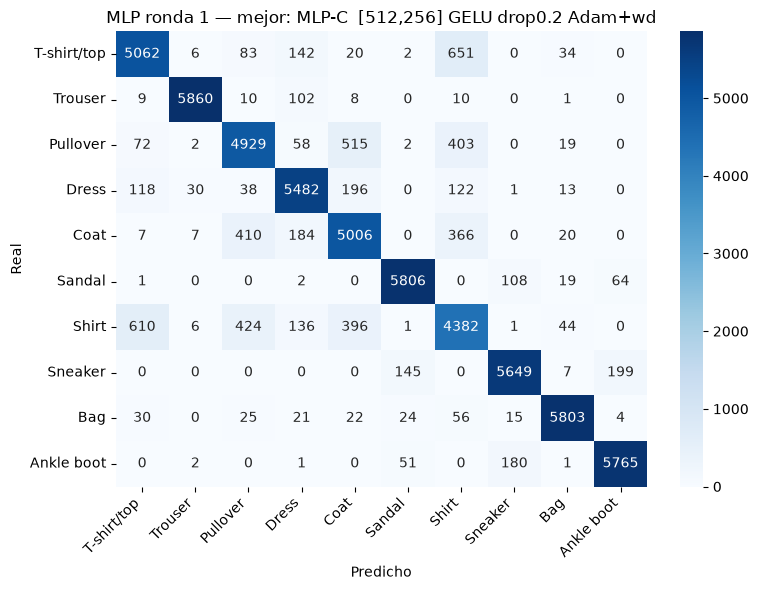

In [107]:
mlp_round1 = [
    dict(name="MLP-A  [256,128] ReLU drop0.3 Adam",
         model_fn=lambda: MLPForCV([256, 128], nn.ReLU, 0.3),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3),
         num_epochs=25),
    dict(name="MLP-B  [512,256,128] ReLU drop0.3 Adam",
         model_fn=lambda: MLPForCV([512, 256, 128], nn.ReLU, 0.3),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3),
         num_epochs=25),
    dict(name="MLP-C  [512,256] GELU drop0.2 Adam+wd",
         model_fn=lambda: MLPForCV([512, 256], nn.GELU, 0.2),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4),
         num_epochs=25),
]

mlp_table, mlp_cms, mlp_best, mlp_best_model = run_and_save_round("MLP ronda 1", mlp_round1)

### 5.3 CNN — Ronda 1 (3 configuraciones)

Tres arquitecturas: baseline chica, una con BatchNorm + dropout + weight decay, y una con
BatchNorm + LeakyReLU.


=== CNN-A  baseline [8,16]->128 ===
  [CNN-A  baseline [8,16]->128] cargado de cache  (acc=0.8986  f1=0.8989  roc=0.9929)

=== CNN-B  BN [32,64]->256,128 dropout+wd ===
  [CNN-B  BN [32,64]->256,128 dropout+wd] cargado de cache  (acc=0.9204  f1=0.9199  roc=0.9954)

=== CNN-C  BN+LeakyReLU [32,64]->128 ===
  [CNN-C  BN+LeakyReLU [32,64]->128] cargado de cache  (acc=0.9163  f1=0.9157  roc=0.9948)

Métricas de 'CNN ronda 1' guardadas en models/metrics/CNN_ronda_1.csv


,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,CNN ronda 1,"CNN-B BN [32,64]->256,128 dropout+wd",0.920367,0.002167,0.920365,0.920367,0.919917,0.001685,0.995444
1,CNN ronda 1,"CNN-C BN+LeakyReLU [32,64]->128",0.916250,0.003341,0.916413,0.916250,0.915692,0.003274,0.994834
2,CNN ronda 1,"CNN-A baseline [8,16]->128",0.898583,0.003095,0.900086,0.898583,0.898908,0.002973,0.992944



Mejor de 'CNN ronda 1': CNN-B  BN [32,64]->256,128 dropout+wd  (f1=0.9199)
Reentrenando sobre todo el train y guardando...
  modelo cargado desde models/best_CNN_ronda_1.pth (no se reentrena)


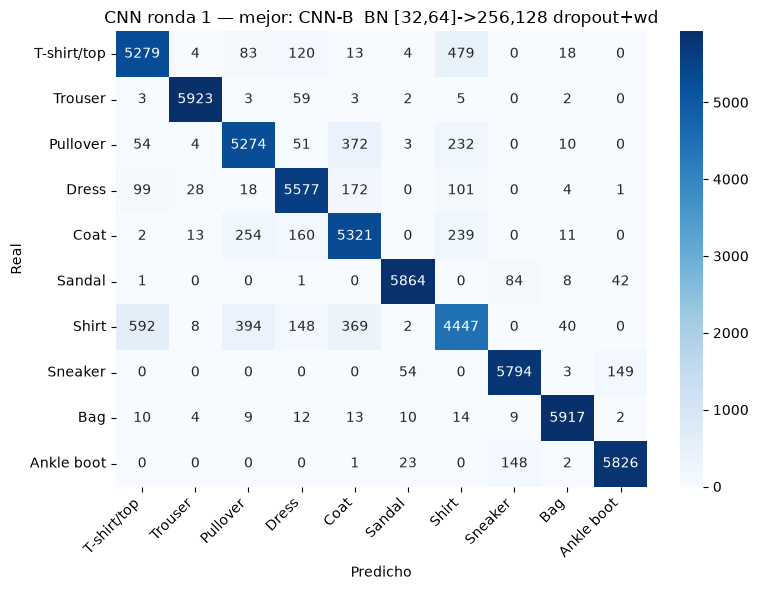

In [108]:
cnn_round1 = [
    dict(name="CNN-A  baseline [8,16]->128",
         model_fn=lambda: build_cnn(
             [ConvLayerConfig(out_channels=8), ConvLayerConfig(out_channels=16)],
             [LinearLayerConfig(out_features=128)]),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3),
         num_epochs=20),
    dict(name="CNN-B  BN [32,64]->256,128 dropout+wd",
         model_fn=lambda: build_cnn(
             [ConvLayerConfig(out_channels=32, use_batchnorm=True),
              ConvLayerConfig(out_channels=64, use_batchnorm=True, dropout_p=0.25)],
             [LinearLayerConfig(out_features=256, dropout_p=0.5),
              LinearLayerConfig(out_features=128, dropout_p=0.25)]),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4),
         num_epochs=20),
    dict(name="CNN-C  BN+LeakyReLU [32,64]->128",
         model_fn=lambda: build_cnn(
             [ConvLayerConfig(out_channels=32, use_batchnorm=True, activation="leaky_relu"),
              ConvLayerConfig(out_channels=64, use_batchnorm=True)],
             [LinearLayerConfig(out_features=128)]),
         build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3),
         num_epochs=20),
]

cnn_table, cnn_cms, cnn_best, cnn_best_model = run_and_save_round("CNN ronda 1", cnn_round1)

### 5.4 Tuning incremental (paso a paso)

Tomamos el mejor de cada tabla y cambiamos **un hiperparámetro a la vez**, re-evaluando con
CV. Plantilla para una ronda de tuning (editar y correr según lo que queramos probar):

Candidatos a barrer, de a uno:
- **learning rate** (1e-3 → 5e-4, 2e-3)
- **dropout** (0.2 / 0.3 / 0.5)
- **ancho / profundidad** de capas
- **optimizador** (Adam / RMSprop / SGD+momentum)
- **regularización** (`weight_decay` L2, `l1_lambda` L1)
- **BatchNorm** sí/no (CNN)
- **épocas**

Vamos a hacer esto juntos, paso a paso, después de ver los resultados de la Ronda 1.

#### Tuning incremental encadenado (greedy)

Tomamos el ganador de la Ronda 1 y vamos cambiando **un hiperparámetro por ronda**. Clave:
cada ronda parte del **ganador de la ronda anterior**, no siempre de la config original. Así, al
terminar la cadena, `mlp_spec` / `cnn_spec` contienen la **mejor combinación** acumulada, que es
la que se lleva a la evaluación final en test (5.5).

Cada ronda incluye la config base (el ganador previo) como referencia — cae en caché, así que es
gratis — y muestra en la tabla si el cambio **mejora o empeora** el `f1_mean`.

In [109]:
# === Motor de tuning secuencial (greedy / coordinate descent) =======================
# Cada ronda PARTE DEL GANADOR de la ronda anterior y cambia un hiperparámetro.
# Así, al terminar la cadena, queda el modelo con la mejor COMBINACIÓN encontrada.
# La config se representa como un dict de hiperparámetros ("spec"); mlp_config/cnn_config
# lo convierten en (model_fn, build_optimizer). tune() arma base + variantes, corre la
# ronda y devuelve (spec_ganador, nombre_ganador) para encadenar con la ronda siguiente.

def _build_optimizer(spec):
    opt, lr, wd = spec["opt"], spec["lr"], spec["wd"]
    if opt == "adam":    return lambda m: optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    if opt == "rmsprop": return lambda m: optim.RMSprop(m.parameters(), lr=lr, weight_decay=wd)
    if opt == "sgd":     return lambda m: optim.SGD(m.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    raise ValueError(f"optimizador desconocido: {opt}")

def mlp_config(name, spec):
    return dict(name=name,
                model_fn=lambda: MLPForCV(spec["hidden"], spec["act"], spec["dropout"]),
                build_optimizer=_build_optimizer(spec),
                num_epochs=spec["epochs"])

def cnn_config(name, spec):
    def build():
        conv = [ConvLayerConfig(out_channels=spec["channels"][0], use_batchnorm=spec["bn"]),
                ConvLayerConfig(out_channels=spec["channels"][1], use_batchnorm=spec["bn"],
                                dropout_p=spec["conv_drop"])]
        lin  = [LinearLayerConfig(out_features=spec["fc"][0], dropout_p=spec["fc_drop"][0]),
                LinearLayerConfig(out_features=spec["fc"][1], dropout_p=spec["fc_drop"][1])]
        return build_cnn(conv, lin)
    return dict(name=name, model_fn=build,
                build_optimizer=_build_optimizer(spec), num_epochs=spec["epochs"])

def tune(round_name, base_spec, base_name, changes, make_config):
    """Ronda secuencial. Parte de (base_spec, base_name) y prueba `changes`:
    lista de (etiqueta, overrides) donde overrides es un dict de hiperparámetros a cambiar
    respecto del ganador previo (normalmente uno solo; el optimizador lleva su lr acoplado).
    Incluye la base (cae en caché) para comparar. Devuelve (spec_ganador, nombre_ganador)."""
    name_to_spec = {base_name: dict(base_spec)}
    configs = [make_config(base_name, dict(base_spec))]
    for label, ov in changes:
        s = dict(base_spec); s.update(ov)
        vname = f"{base_name} + {label}"
        name_to_spec[vname] = s
        configs.append(make_config(vname, s))
    table, cms, best_name, best_model = run_and_save_round(round_name, configs)
    best_spec = name_to_spec[best_name]
    nota = "(sin cambio: ganó la base)" if best_name == base_name else "(cambió el ganador)"
    print(f"\n[{round_name}] -> ganador: {best_name}  {nota}")
    return best_spec, best_name

##### Cadena de tuning — MLP

In [110]:
# Punto de partida MLP: ganador de la Ronda 1 (MLP-C). A partir de acá se encadena.
mlp_spec = dict(hidden=[512, 256], act=nn.GELU, dropout=0.2,
                opt="adam", lr=1e-3, wd=1e-4, epochs=25)
mlp_name = "MLP-C  [512,256] GELU drop0.2 Adam+wd"   # nombre cacheado de la Ronda 1


=== MLP-C  [512,256] GELU drop0.2 Adam+wd ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd] cargado de cache  (acc=0.8957  f1=0.8958  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4] fold 1/5  acc=0.8934  f1=0.8942  roc=0.9928
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4] fold 2/5  acc=0.8913  f1=0.8912  roc=0.9924
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4] fold 3/5  acc=0.8918  f1=0.8914  roc=0.9924
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4] fold 4/5  acc=0.8918  f1=0.8914  roc=0.9925
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=5e-4] fold 5/5  acc=0.8888  f1=0.8882  roc=0.9917

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=2e-3 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=2e-3] fold 1/5  acc=0.8964  f1=0.8965  roc=0.9931
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=2e-3] fold 2/5  acc=0.8915  f1=0.8913  roc=0.9921
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + lr=2e-3] fold 3/5  acc=0.889

,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 2 (lr),"MLP-C [512,256] GELU drop0.2 Adam+wd",0.895733,0.004015,0.896197,0.895733,0.895788,0.004099,0.992621
1,MLP ronda 2 (lr),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=5e-4",0.891400,0.001684,0.892011,0.891400,0.891267,0.002128,0.992356
2,MLP ronda 2 (lr),"MLP-C [512,256] GELU drop0.2 Adam+wd + lr=2e-3",0.890917,0.004193,0.891526,0.890917,0.890523,0.004372,0.992201



Mejor de 'MLP ronda 2 (lr)': MLP-C  [512,256] GELU drop0.2 Adam+wd  (f1=0.8958)
Reentrenando sobre todo el train y guardando...
  modelo guardado en models/best_MLP_ronda_2_lr.pth


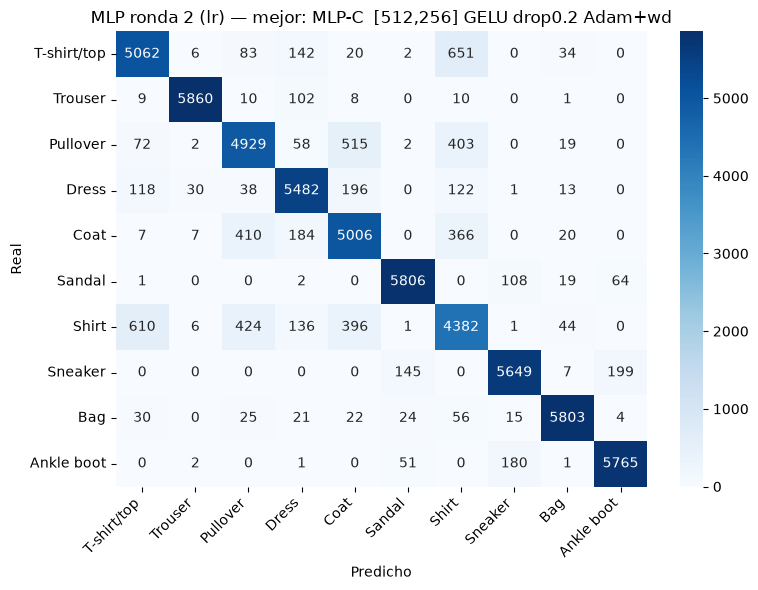


[MLP ronda 2 (lr)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd  (sin cambio: ganó la base)


In [111]:
# Ronda 2 — learning rate
mlp_spec, mlp_name = tune("MLP ronda 2 (lr)", mlp_spec, mlp_name,
    [("lr=5e-4", {"lr": 5e-4}), ("lr=2e-3", {"lr": 2e-3})], mlp_config)


=== MLP-C  [512,256] GELU drop0.2 Adam+wd ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd] cargado de cache  (acc=0.8957  f1=0.8958  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.1 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.1] fold 1/5  acc=0.8899  f1=0.8895  roc=0.9924
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.1] fold 2/5  acc=0.8936  f1=0.8936  roc=0.9923
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.1] fold 3/5  acc=0.8968  f1=0.8965  roc=0.9925
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.1] fold 4/5  acc=0.8907  f1=0.8903  roc=0.9922
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.1] fold 5/5  acc=0.8976  f1=0.8977  roc=0.9927

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.3 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.3] fold 1/5  acc=0.8966  f1=0.8966  roc=0.9930
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.3] fold 2/5  acc=0.8938  f1=0.8939  roc=0.9927
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + drop=0.3] fold 3/5 

,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 3 (dropout),"MLP-C [512,256] GELU drop0.2 Adam+wd",0.895733,0.004015,0.896197,0.895733,0.895788,0.004099,0.992621
1,MLP ronda 3 (dropout),"MLP-C [512,256] GELU drop0.2 Adam+wd + drop=0.3",0.894350,0.002240,0.894624,0.894350,0.894126,0.002278,0.992583
2,MLP ronda 3 (dropout),"MLP-C [512,256] GELU drop0.2 Adam+wd + drop=0.1",0.893717,0.003479,0.894143,0.893717,0.893526,0.003620,0.992433
3,MLP ronda 3 (dropout),"MLP-C [512,256] GELU drop0.2 Adam+wd + drop=0.4",0.892467,0.004212,0.893526,0.892467,0.892409,0.004174,0.992282



Mejor de 'MLP ronda 3 (dropout)': MLP-C  [512,256] GELU drop0.2 Adam+wd  (f1=0.8958)
Reentrenando sobre todo el train y guardando...
  modelo guardado en models/best_MLP_ronda_3_dropout.pth


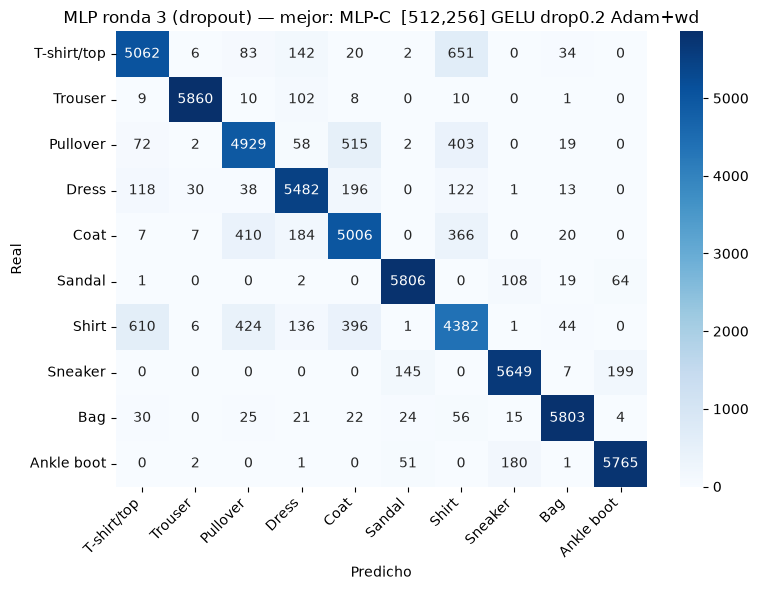


[MLP ronda 3 (dropout)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd  (sin cambio: ganó la base)


In [112]:
# Ronda 3 — dropout
mlp_spec, mlp_name = tune("MLP ronda 3 (dropout)", mlp_spec, mlp_name,
    [("drop=0.1", {"dropout": 0.1}), ("drop=0.3", {"dropout": 0.3}), ("drop=0.4", {"dropout": 0.4})], mlp_config)


=== MLP-C  [512,256] GELU drop0.2 Adam+wd ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd] cargado de cache  (acc=0.8957  f1=0.8958  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + [256,128] ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + [256,128]] fold 1/5  acc=0.8866  f1=0.8865  roc=0.9919
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + [256,128]] fold 2/5  acc=0.8792  f1=0.8798  roc=0.9911
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + [256,128]] fold 3/5  acc=0.8919  f1=0.8917  roc=0.9922
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + [256,128]] fold 4/5  acc=0.8883  f1=0.8874  roc=0.9918
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + [256,128]] fold 5/5  acc=0.8911  f1=0.8908  roc=0.9918

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + [512,256,128] ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + [512,256,128]] fold 1/5  acc=0.8958  f1=0.8960  roc=0.9927
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + [512,256,128]] fold 2/5  acc=0.8842  f1=0.8835  roc=0.9915
  [MLP-C  [512,256] GELU drop0.2 Adam+wd 

,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 4 (capacidad),"MLP-C [512,256] GELU drop0.2 Adam+wd",0.895733,0.004015,0.896197,0.895733,0.895788,0.004099,0.992621
1,MLP ronda 4 (capacidad),"MLP-C [512,256] GELU drop0.2 Adam+wd + [1024,...",0.891000,0.003186,0.891013,0.891000,0.890486,0.003439,0.992235
2,MLP ronda 4 (capacidad),"MLP-C [512,256] GELU drop0.2 Adam+wd + [512,2...",0.890517,0.004248,0.890991,0.890517,0.890195,0.004637,0.992159
3,MLP ronda 4 (capacidad),"MLP-C [512,256] GELU drop0.2 Adam+wd + [256,128]",0.887433,0.005048,0.887904,0.887433,0.887241,0.004707,0.991778



Mejor de 'MLP ronda 4 (capacidad)': MLP-C  [512,256] GELU drop0.2 Adam+wd  (f1=0.8958)
Reentrenando sobre todo el train y guardando...
  modelo guardado en models/best_MLP_ronda_4_capacidad.pth


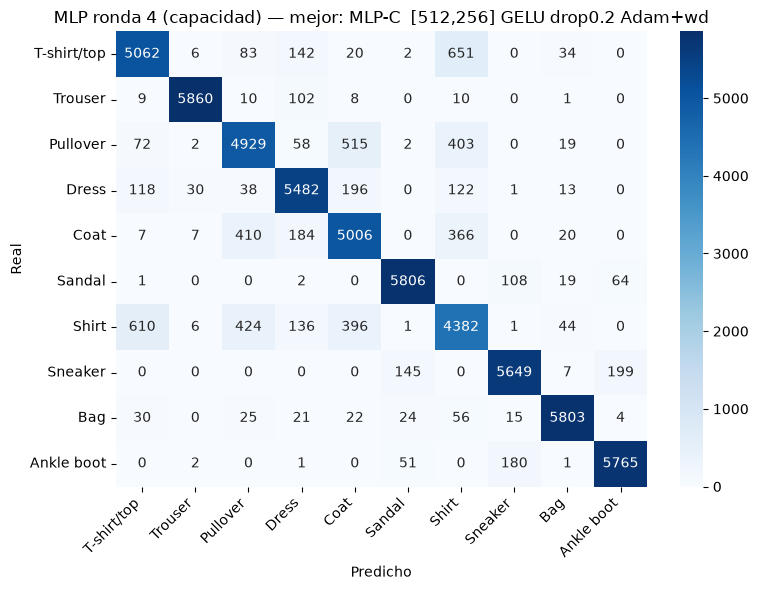


[MLP ronda 4 (capacidad)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd  (sin cambio: ganó la base)


In [113]:
# Ronda 4 — capacidad (ancho/profundidad)
mlp_spec, mlp_name = tune("MLP ronda 4 (capacidad)", mlp_spec, mlp_name,
    [("[256,128]", {"hidden": [256,128]}), ("[512,256,128]", {"hidden": [512,256,128]}), ("[1024,512]", {"hidden": [1024,512]})], mlp_config)


=== MLP-C  [512,256] GELU drop0.2 Adam+wd ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd] cargado de cache  (acc=0.8957  f1=0.8958  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=0 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=0] fold 1/5  acc=0.8982  f1=0.8984  roc=0.9930
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=0] fold 2/5  acc=0.8951  f1=0.8951  roc=0.9927
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=0] fold 3/5  acc=0.8912  f1=0.8911  roc=0.9922
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=0] fold 4/5  acc=0.8953  f1=0.8956  roc=0.9928
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=0] fold 5/5  acc=0.8938  f1=0.8938  roc=0.9923

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=5e-4 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=5e-4] fold 1/5  acc=0.8922  f1=0.8922  roc=0.9928
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=5e-4] fold 2/5  acc=0.8958  f1=0.8957  roc=0.9927
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + wd=5e-4] fold 3/5  acc=0.8885  f1=0.8880  roc=

,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 5 (weight_decay),"MLP-C [512,256] GELU drop0.2 Adam+wd",0.895733,0.004015,0.896197,0.895733,0.895788,0.004099,0.992621
1,MLP ronda 5 (weight_decay),"MLP-C [512,256] GELU drop0.2 Adam+wd + wd=0",0.894717,0.002540,0.895323,0.894717,0.894778,0.002650,0.992611
2,MLP ronda 5 (weight_decay),"MLP-C [512,256] GELU drop0.2 Adam+wd + wd=5e-4",0.891067,0.004807,0.891179,0.891067,0.890897,0.004929,0.992325



Mejor de 'MLP ronda 5 (weight_decay)': MLP-C  [512,256] GELU drop0.2 Adam+wd  (f1=0.8958)
Reentrenando sobre todo el train y guardando...
  modelo guardado en models/best_MLP_ronda_5_weight_decay.pth


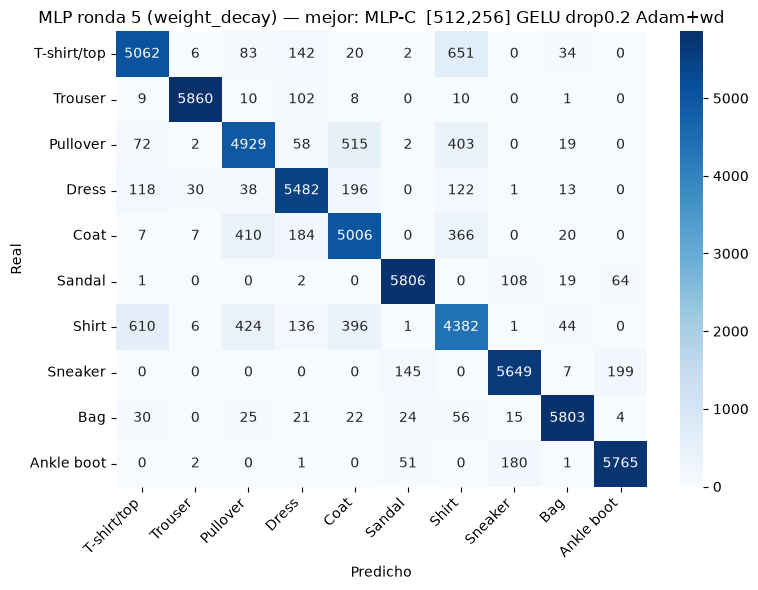


[MLP ronda 5 (weight_decay)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd  (sin cambio: ganó la base)


In [114]:
# Ronda 5 — weight decay (L2)
mlp_spec, mlp_name = tune("MLP ronda 5 (weight_decay)", mlp_spec, mlp_name,
    [("wd=0", {"wd": 0.0}), ("wd=5e-4", {"wd": 5e-4})], mlp_config)


=== MLP-C  [512,256] GELU drop0.2 Adam+wd ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd] cargado de cache  (acc=0.8957  f1=0.8958  roc=0.9926)

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + RMSprop ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + RMSprop] fold 1/5  acc=0.8776  f1=0.8754  roc=0.9908
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + RMSprop] fold 2/5  acc=0.8820  f1=0.8821  roc=0.9913
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + RMSprop] fold 3/5  acc=0.8871  f1=0.8869  roc=0.9919
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + RMSprop] fold 4/5  acc=0.8896  f1=0.8891  roc=0.9923
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + RMSprop] fold 5/5  acc=0.8840  f1=0.8830  roc=0.9913

=== MLP-C  [512,256] GELU drop0.2 Adam+wd + SGD+mom lr=1e-2 ===
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + SGD+mom lr=1e-2] fold 1/5  acc=0.8893  f1=0.8894  roc=0.9919
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + SGD+mom lr=1e-2] fold 2/5  acc=0.8835  f1=0.8838  roc=0.9910
  [MLP-C  [512,256] GELU drop0.2 Adam+wd + SGD+

,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,MLP ronda 6 (optimizador),"MLP-C [512,256] GELU drop0.2 Adam+wd",0.895733,0.004015,0.896197,0.895733,0.895788,0.004099,0.992621
1,MLP ronda 6 (optimizador),"MLP-C [512,256] GELU drop0.2 Adam+wd + SGD+mo...",0.885367,0.002293,0.885299,0.885367,0.885123,0.002410,0.991396
2,MLP ronda 6 (optimizador),"MLP-C [512,256] GELU drop0.2 Adam+wd + RMSprop",0.884050,0.004633,0.884960,0.884050,0.883272,0.005250,0.991499



Mejor de 'MLP ronda 6 (optimizador)': MLP-C  [512,256] GELU drop0.2 Adam+wd  (f1=0.8958)
Reentrenando sobre todo el train y guardando...
  modelo guardado en models/best_MLP_ronda_6_optimizador.pth


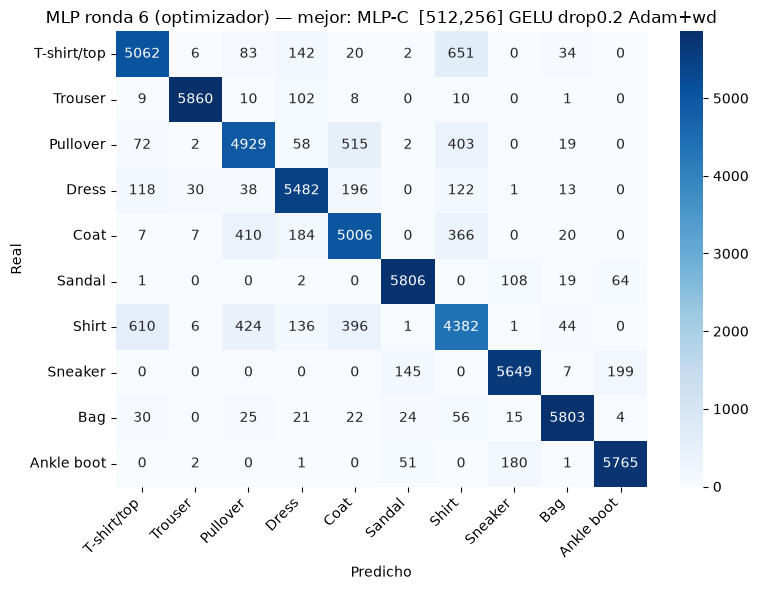


[MLP ronda 6 (optimizador)] -> ganador: MLP-C  [512,256] GELU drop0.2 Adam+wd  (sin cambio: ganó la base)


In [115]:
# Ronda 6 — optimizador (SGD lleva su lr acoplado)
mlp_spec, mlp_name = tune("MLP ronda 6 (optimizador)", mlp_spec, mlp_name,
    [("RMSprop", {"opt": "rmsprop"}), ("SGD+mom lr=1e-2", {"opt": "sgd", "lr": 1e-2})], mlp_config)

##### Cadena de tuning — CNN

In [116]:
# Punto de partida CNN: ganador de la Ronda 1 (CNN-B). A partir de acá se encadena.
cnn_spec = dict(channels=[32, 64], conv_drop=0.25, fc=[256, 128], fc_drop=[0.5, 0.25],
                bn=True, opt="adam", lr=1e-3, wd=1e-4, epochs=20)
cnn_name = "CNN-B  BN [32,64]->256,128 dropout+wd"   # nombre cacheado de la Ronda 1


=== CNN-B  BN [32,64]->256,128 dropout+wd ===
  [CNN-B  BN [32,64]->256,128 dropout+wd] cargado de cache  (acc=0.9204  f1=0.9199  roc=0.9954)

=== CNN-B  BN [32,64]->256,128 dropout+wd + lr=5e-4 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=5e-4] fold 1/5  acc=0.9203  f1=0.9205  roc=0.9955
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=5e-4] fold 2/5  acc=0.9225  f1=0.9218  roc=0.9956
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=5e-4] fold 3/5  acc=0.9178  f1=0.9171  roc=0.9952
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=5e-4] fold 4/5  acc=0.9175  f1=0.9166  roc=0.9952
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=5e-4] fold 5/5  acc=0.9211  f1=0.9197  roc=0.9954

=== CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3] fold 1/5  acc=0.9231  f1=0.9233  roc=0.9956
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3] fold 2/5  acc=0.9228  f1=0.9232  roc=0.9955
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3] fold 3/5  acc=0.924

,round,model,acc_mean,acc_std,prec_mean,rec_mean,f1_mean,f1_std,roc_mean
0,CNN ronda 2 (lr),"CNN-B BN [32,64]->256,128 dropout+wd + lr=2e-3",0.923083,0.001226,0.923307,0.923083,0.923001,0.001282,0.995615
1,CNN ronda 2 (lr),"CNN-B BN [32,64]->256,128 dropout+wd",0.920367,0.002167,0.920365,0.920367,0.919917,0.001685,0.995444
2,CNN ronda 2 (lr),"CNN-B BN [32,64]->256,128 dropout+wd + lr=5e-4",0.919833,0.002138,0.920042,0.919833,0.919157,0.002238,0.995391



Mejor de 'CNN ronda 2 (lr)': CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3  (f1=0.9230)
Reentrenando sobre todo el train y guardando...
  modelo guardado en models/best_CNN_ronda_2_lr.pth


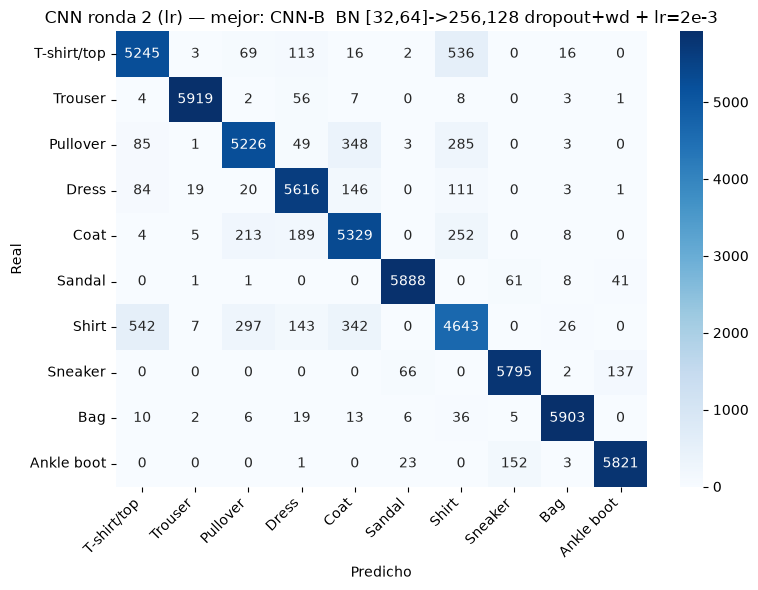


[CNN ronda 2 (lr)] -> ganador: CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3  (cambió el ganador)


In [117]:
# Ronda 2 — learning rate
cnn_spec, cnn_name = tune("CNN ronda 2 (lr)", cnn_spec, cnn_name,
    [("lr=5e-4", {"lr": 5e-4}), ("lr=2e-3", {"lr": 2e-3})], cnn_config)

In [ ]:
# Ronda 3 — dropout (en la 2da conv)
cnn_spec, cnn_name = tune("CNN ronda 3 (dropout)", cnn_spec, cnn_name,
    [("conv_drop=0.1", {"conv_drop": 0.1}), ("conv_drop=0.4", {"conv_drop": 0.4})], cnn_config)


=== CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3] cargado de cache  (acc=0.9231  f1=0.9230  roc=0.9956)

=== CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3 + conv_drop=0.1 ===
  [CNN-B  BN [32,64]->256,128 dropout+wd + lr=2e-3 + conv_drop=0.1] fold 1/5  acc=0.9192  f1=0.9184  roc=0.9953


In [ ]:
# Ronda 4 — capacidad (canales convolucionales)
cnn_spec, cnn_name = tune("CNN ronda 4 (capacidad)", cnn_spec, cnn_name,
    [("[16,32]", {"channels": [16,32]}), ("[64,128]", {"channels": [64,128]})], cnn_config)

In [ ]:
# Ronda 5 — weight decay (L2)
cnn_spec, cnn_name = tune("CNN ronda 5 (weight_decay)", cnn_spec, cnn_name,
    [("wd=0", {"wd": 0.0}), ("wd=5e-4", {"wd": 5e-4})], cnn_config)

In [ ]:
# Ronda 6 — optimizador (SGD lleva su lr acoplado)
cnn_spec, cnn_name = tune("CNN ronda 6 (optimizador)", cnn_spec, cnn_name,
    [("RMSprop", {"opt": "rmsprop"}), ("SGD+mom lr=1e-2", {"opt": "sgd", "lr": 1e-2})], cnn_config)

### 5.5 Evaluación final en test (held-out)

Una vez elegidos los mejores MLP y CNN, se reentrenan sobre **todo** el train y se evalúan
en `test_set`, que no participó en la selección. Esta es la métrica que decide el modelo final.

In [ ]:
def evaluate_on_test(name, model_fn, build_optimizer, num_epochs,
                     l1_lambda=0.0, patience=PATIENCE, batch_size=512, force=False):
    """
    Reentrena el modelo sobre TODO el train (con early stopping) y lo evalúa en el test held-out.
    Guarda el modelo en models/<name>_final.pth y lo carga si ya existe (no reentrena).
    """
    path = os.path.join(FINAL_DIR, f"{_slug(name)}_final.pth")
    model = model_fn().to(device)

    if not force and not FORCE_RECOMPUTE and os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        print(f"Modelo cargado desde {path} (no se reentrena)")
    else:
        criterion = nn.CrossEntropyLoss()
        optimizer = build_optimizer(model)
        idx = np.arange(len(train_full))
        if patience > 0:
            tr_idx, va_idx = train_test_split(
                idx, test_size=INNER_VAL_FRAC, random_state=SEED, stratify=cv_labels)
            train_loader = GPULoader(X_train_gpu, Y_train_gpu, tr_idx, batch_size, True)
            es_loader    = GPULoader(X_train_gpu, Y_train_gpu, va_idx, batch_size, False)
        else:
            train_loader = GPULoader(X_train_gpu, Y_train_gpu, None, batch_size, True)
            es_loader    = None
        print(f"Entrenando {name} sobre el train completo (máx {num_epochs} épocas, early stopping)...")
        _fit(model, train_loader, es_loader, criterion, optimizer, num_epochs, l1_lambda, patience)
        torch.save(model.state_dict(), path)
        print(f"Modelo guardado en {path}")

    test_loader_eval = GPULoader(X_test_gpu, Y_test_gpu, None, batch_size, False)
    y_true, y_pred, y_proba = _predict(model, test_loader_eval)

    print(f"\n=== Test — {name} ===")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    roc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    print(f"ROC-AUC (macro, OvR): {roc:.4f}")
    plot_cm(confusion_matrix(y_true, y_pred, labels=list(range(10))), f"Test — {name}")
    plot_roc(y_true, y_proba, f"ROC (test) — {name}")
    return model

# Ejemplo de uso una vez decididos los ganadores (descomentar y ajustar):
# best_mlp = evaluate_on_test("MLP final",
#     model_fn=lambda: MLPForCV([512, 256, 128], nn.ReLU, 0.3),
#     build_optimizer=lambda m: optim.Adam(m.parameters(), lr=1e-3), num_epochs=30)

Entrenando MLP final (C) sobre el train completo (máx 25 épocas, early stopping)...
Modelo guardado en models/MLP_final_C_final.pth

=== Test — MLP final (C) ===
              precision    recall  f1-score   support

 T-shirt/top     0.8649    0.8450    0.8548      1000
     Trouser     0.9878    0.9730    0.9804      1000
    Pullover     0.7998    0.8110    0.8054      1000
       Dress     0.8677    0.9180    0.8921      1000
        Coat     0.7868    0.8450    0.8149      1000
      Sandal     0.9874    0.9440    0.9652      1000
       Shirt     0.7620    0.6820    0.7198      1000
     Sneaker     0.9338    0.9740    0.9535      1000
         Bag     0.9759    0.9720    0.9739      1000
  Ankle boot     0.9641    0.9660    0.9650      1000

    accuracy                         0.8930     10000
   macro avg     0.8930    0.8930    0.8925     10000
weighted avg     0.8930    0.8930    0.8925     10000

ROC-AUC (macro, OvR): 0.9920


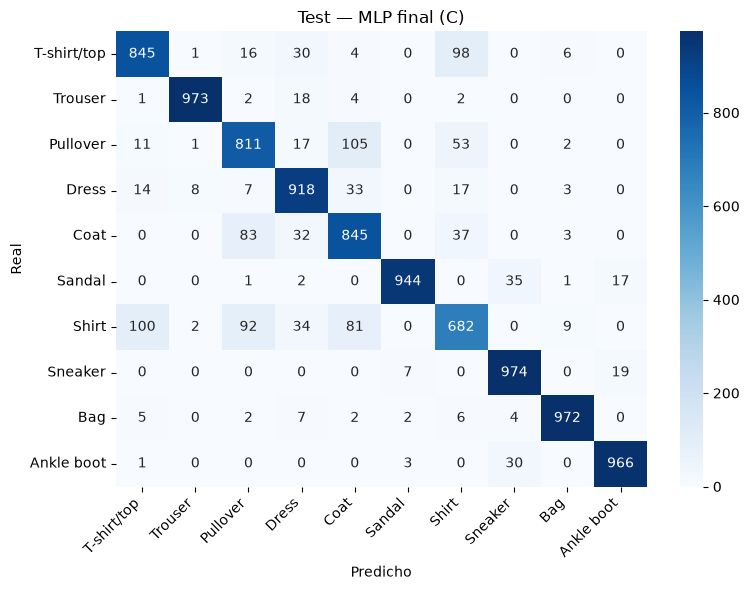

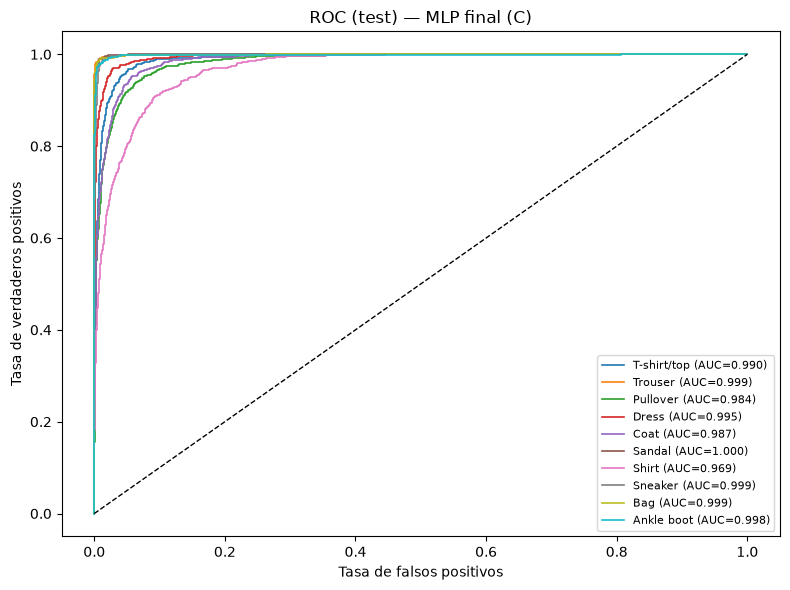

Entrenando CNN final (B) sobre el train completo (máx 20 épocas, early stopping)...
Modelo guardado en models/CNN_final_B_final.pth

=== Test — CNN final (B) ===
              precision    recall  f1-score   support

 T-shirt/top     0.8621    0.9000    0.8806      1000
     Trouser     0.9929    0.9850    0.9890      1000
    Pullover     0.9026    0.8530    0.8771      1000
       Dress     0.9160    0.9380    0.9269      1000
        Coat     0.8590    0.9080    0.8828      1000
      Sandal     0.9899    0.9790    0.9844      1000
       Shirt     0.7896    0.7430    0.7656      1000
     Sneaker     0.9515    0.9810    0.9660      1000
         Bag     0.9899    0.9820    0.9859      1000
  Ankle boot     0.9807    0.9660    0.9733      1000

    accuracy                         0.9235     10000
   macro avg     0.9234    0.9235    0.9232     10000
weighted avg     0.9234    0.9235    0.9232     10000

ROC-AUC (macro, OvR): 0.9954


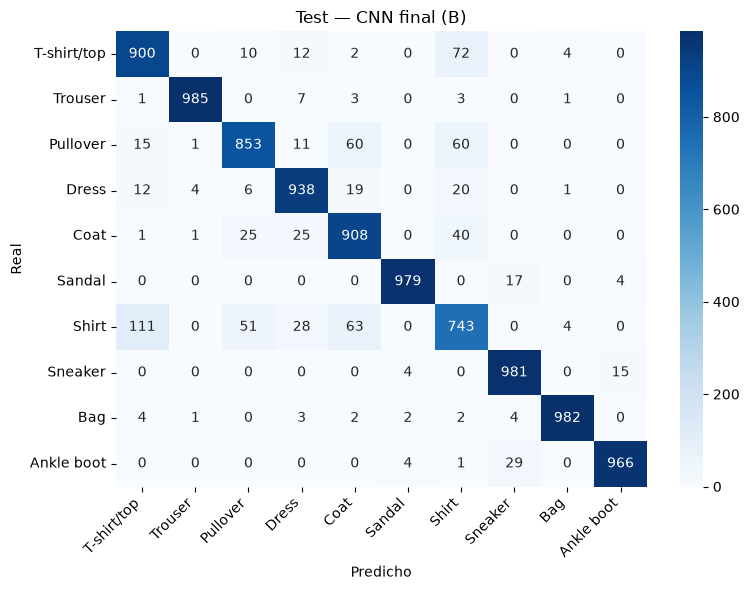

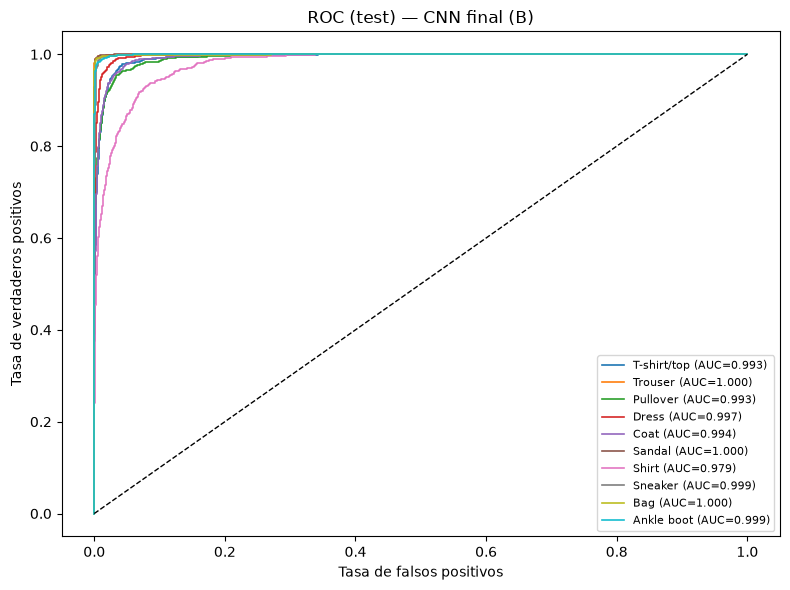

In [ ]:
# === Evaluación final en test + guardado del GANADOR de toda la cadena de tuning =====
# mlp_spec / cnn_spec contienen la mejor combinación acumulada (ver sección 5.4).
# Esta es la ÚNICA vez que se toca el test held-out.

mlp_final = mlp_config("MLP final", mlp_spec)
best_mlp = evaluate_on_test(mlp_final["name"], model_fn=mlp_final["model_fn"],
                            build_optimizer=mlp_final["build_optimizer"],
                            num_epochs=mlp_final["num_epochs"])

cnn_final = cnn_config("CNN final", cnn_spec)
best_cnn = evaluate_on_test(cnn_final["name"], model_fn=cnn_final["model_fn"],
                            build_optimizer=cnn_final["build_optimizer"],
                            num_epochs=cnn_final["num_epochs"])

# 6. Discusión

# 7. Conclusiones y Trabajo Futuro